# Convert the SCSS-net data into nii.gz for nnUNet

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.transform import resize
import nibabel as nib

import sys
sys.path.append('../Codes/functions')
from preprocessing_functions import find_304_match, normalizing_data, crop_data

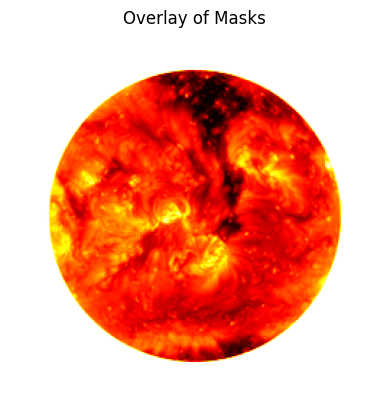

(256, 256)
(256, 256)


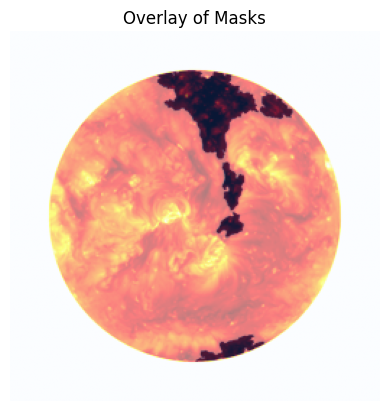

(256, 256)
(256, 256)


In [22]:
name_img = r"2016_02_27__23_00_05_84__SDO_AIA_AIA_193" + r".png"

# #images_sure
# path_folder_img = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs_sure" + r"/"
# path_folder_label = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\labelsTs_sure" + r"/"

# #general
# path_folder_img = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs" + r"/"
# path_folder_label = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\labelsTs" + r"/"

#New download

path_folder_img = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193\193_train\193(region_growth)\imgs" + r"/"
path_folder_label = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193\193_train\193(region_growth)\masks" + r"/"


img = np.array(Image.open(path_folder_img + name_img).convert("L"))
label = np.array(Image.open(path_folder_label + name_img).convert("L"))
plt.imshow(img, cmap="hot")
#plt.imshow(label, cmap="Blues", alpha=0.5)
plt.title("Overlay of Masks")
plt.axis("off")
plt.show()

print(img.shape)
print(label.shape)


img = np.array(Image.open(path_folder_img + name_img).convert("L"))
label = np.array(Image.open(path_folder_label + name_img).convert("L"))
plt.imshow(img, cmap="hot")
plt.imshow(label, cmap="Blues", alpha=0.5)
plt.title("Overlay of Masks")
plt.axis("off")
plt.show()

print(img.shape)
print(label.shape)


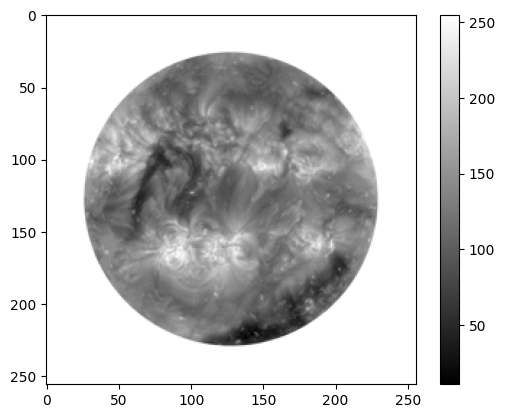

False


In [ ]:
# Open PNG
img = Image.open(r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\193_train\193(region_growth)\imgs\2012_01_01__23_00_07_84__SDO_AIA_AIA_193.png").convert("L")


img_array = np.array(img)
#img_array = (img_array > 0).astype(np.uint8)

# Show the image
plt.imshow(img_array, cmap="gray")  # or use cmap=plt.colormaps['afmhot']
plt.colorbar()
plt.show()

# Print raw values
print(img_array.shape != (256,256))   # dimensions (H, W) or (H, W, 3) for RGB
#print(img_array)         # pixel values as a matrix
#print(img_array[150])

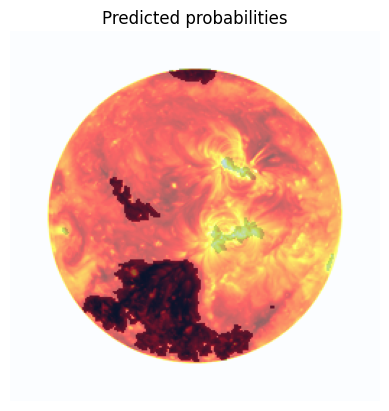

In [7]:
import nibabel as nib


gt_label = nib.load(r"C:\Users\User\nnUNet\nnUNet_raw\Dataset364_SDO_AIA\labelsTr\case_4129.nii.gz").get_fdata()
img_sun = nib.load(r"C:\Users\User\nnUNet\nnUNet_raw\Dataset364_SDO_AIA\imagesTr\case_4129_0001.nii.gz").get_fdata()


#gt_label = np.rot90(gt_label, k=2)


# Quick display
#plt.imshow(pred_700, cmap="hot")  # 2D array, probabilities
# plt.imshow(pred_800, cmap= "Reds")
plt.imshow(img_sun, cmap= "hot")

#plt.imshow(pred_350, cmap= "Greens", alpha = 0.4)
#plt.imshow(pred_50, cmap= "Reds", alpha = 0.4)
#plt.imshow(pred_200, cmap= "Reds", alpha = 0.4)
plt.imshow(gt_label, cmap ="Blues", alpha = 0.4)
plt.axis("off")
plt.title("Predicted probabilities")
plt.show()

# Mass conversion

## images -Tr/Ts

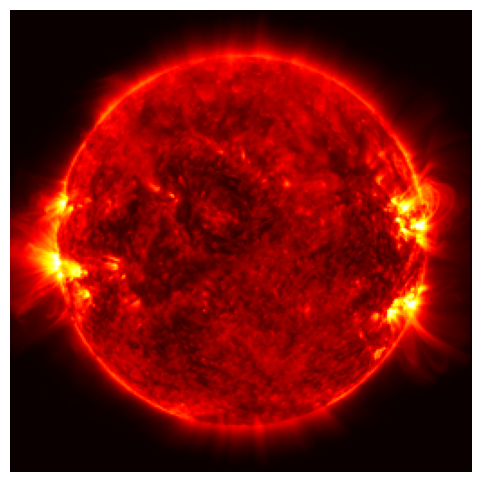

359


In [7]:
# Modifications made. They work.
# These modifications were done cause i don't know if i cropped the 171A data or just if they are (same with normalized).

# Path for 193A images:
##TR: Training set
#input_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\193_train\193(region_growth)\imgs"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\imagesTr"
##TS: test set
#input_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\193_test\imgs"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\imagesTs"


## Path for 171A images:    /!\ change numerification by adding a number 
##TR: Training set
#input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\imgs"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\imagesTr"
# & 
#input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(zooniverse)\imgs"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\imagesTr"
# -------------------
#TS: test set
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_test\imgs"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\imagesTs"


# 
# input_dir = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset195_SDO_AIA\imagesTs"

# NEW DATA "CLEANED" for 196
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193_CLEANED\imagesTr"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset196_SDO_AIA\imagesTr"


input_dir = r"REEEEAAAD, dont forget the percentile_top_limite if needed"
output_dir = r"REEEEAAAD, dont forget the percentile_top_limite if needed"
input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_test\imgs"
output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\imagesTs"

png_files = [f for f in os.listdir(input_dir) if f.lower().endswith(".png")]

for idx, filename in enumerate(png_files):
    # Load PNG as grayscale
    img_path = os.path.join(input_dir, filename)
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)
    if img_array.shape != (256,256):
        print(f"resizing of image: {img_path}")
        resized_img = resize(img_array, (256, 256), order=3, preserve_range=True, anti_aliasing=True)
    else:
        resized_img = img_array
    array_closest_img = [resized_img]
    #norm_img = normalizing_data(array_closest_img)
    #finale_img = crop_data(array_closest_img) #norm_img
    #finale_img = finale_img[0]


    
    #sitk_img = sitk.GetImageFromArray(finale_img)
    sitk_img = sitk.GetImageFromArray(array_closest_img[0])
    # Zero-padded case ID
    case_id = str(idx).zfill(4)  # 0000, 0001, 0002, ...
    output_name = f"case_{case_id}_0000.nii.gz"

    # Full output path
    output_path = os.path.join(output_dir, output_name)

    # Checking
    if case_id == "0000":
        plt.figure(figsize=(6,6))
        #plt.imshow(finale_img, cmap="hot")
        plt.imshow(array_closest_img[0], cmap="hot")
        
        plt.axis("off")
        plt.show()
        

    # Save as NIfTI
    sitk.WriteImage(sitk_img, output_path)
print(idx)

## labels -Tr/Ts

In [3]:
# input_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\193_train\193(region_growth)\masks"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset193_SDO_AIA\labelsTr"

# input_dir = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\labelsTs"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset195_SDO_AIA\labelsTs\spoca"

# NEW DATA "CLEANED" for 196
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193\labelsTr"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset196_SDO_AIA\imagesTr"

## Path for 171A images:    /!\ change numerification by adding a number 4364
##TR: Training set
#input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\masks"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\labelsTr"
# & 
#input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(zooniverse)\masks"
#output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\labelsTr"
# -------------------
#TS: test set
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_test\masks(spoca)"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset171_SDO_AIA\labelsTs"



input_dir = r"REAAAAAD"
output_dir = r"REAAAAAAD"

input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\304"
output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset304_SDO_AIA\labelsTs"

png_files = [f for f in os.listdir(input_dir) if f.lower().endswith(".png")]

for idx, filename in enumerate(png_files):
    # Load PNG as grayscale
    img_path = os.path.join(input_dir, filename)
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)
    img_array = (img_array > 0).astype(np.uint8)
    
    sitk_img = sitk.GetImageFromArray(img_array)

    case_id = str(idx).zfill(4)  # 0000, 0001, 0002, ...
    output_name = f"case_{case_id}.nii.gz"

    output_path = os.path.join(output_dir, output_name)

    sitk.WriteImage(sitk_img, output_path)
print(idx)

17


In [4]:
import os


labels_dir = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs"
images_dir = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs_sure"

# List file names without extension
labels = sorted([os.path.splitext(f)[0] for f in os.listdir(labels_dir)])
images = sorted([os.path.splitext(f)[0] for f in os.listdir(images_dir)])

# Missing in images
missing_in_images = sorted(list(set(labels) - set(images)))

# Missing in labels
missing_in_labels = sorted(list(set(images) - set(labels)))

print("❌ Files in labelsTs missing in imagesTs (with indexes):")
for idx, f in enumerate(missing_in_images):
    print(f"{idx}: {f}")

print("\n❌ Files in imagesTs missing in labelsTs (with indexes):")
for idx, f in enumerate(missing_in_labels):
    print(f"{idx}: {f}")

print("\nDone.")



❌ Files in labelsTs missing in imagesTs (with indexes):

❌ Files in imagesTs missing in labelsTs (with indexes):
0: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193
1: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r180
2: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r270
3: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r90
4: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193
5: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r180
6: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r270
7: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r90
8: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193
9: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r180
10: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r270
11: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r90
12: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193
13: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r180
14: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r270
15: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r90
16: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193
17: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193_r180
18: 2018_03_30__05_32_28_8

Indivudual ones

In [28]:
import json
summary_file = r"C:\Users\User\nnUNet\nnUNet_predictions\Dataset195_SDO_AIA\nnUNetTrainer__Fixed4StagePlannerPlans__2d\summary_spoca_checkpoint_epoch_50_with_tta.json"

with open(summary_file, "r") as f:
    data = json.load(f)

bad_cases = []

for case in data["metric_per_case"]:
    dice = case["metrics"]["1"]["Dice"]
    if dice <= 0.5:
        filename = os.path.basename(case["prediction_file"])
        bad_cases.append((filename, dice))

print("Cases with Dice ≤ 0.5:\n")
for filename, dice in bad_cases:
    print(f"{filename}  --> Dice = {dice:.4f}")

Cases with Dice ≤ 0.5:



## Minimum list of bad samples:

❌ Files in labelsTs missing in imagesTs (with indexes):

❌ Files in imagesTs missing in labelsTs (with indexes):
0: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193
1: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r180
2: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r270
3: 2016_10_24__22_59_53_85__SDO_AIA_AIA_193_r90
4: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193
5: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r180
6: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r270
7: 2016_10_25__23_00_17_84__SDO_AIA_AIA_193_r90
8: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193
9: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r180
10: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r270
11: 2016_11_21__22_59_41_84__SDO_AIA_AIA_193_r90
12: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193
13: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r180
14: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r270
15: 2018_03_29__05_48_40_84__SDO_AIA_AIA_193_r90
16: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193
17: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193_r180
18: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193_r270
19: 2018_03_30__05_32_28_84__SDO_AIA_AIA_193_r90
20: 2018_03_31__03_45_28_84__SDO_AIA_AIA_193
21: 2018_03_31__03_45_28_84__SDO_AIA_AIA_193_r180
22: 2018_03_31__03_45_28_84__SDO_AIA_AIA_193_r270
23: 2018_03_31__03_45_28_84__SDO_AIA_AIA_193_r90
24: 2018_04_01__04_00_40_84__SDO_AIA_AIA_193
25: 2018_04_01__04_00_40_84__SDO_AIA_AIA_193_r180
26: 2018_04_01__04_00_40_84__SDO_AIA_AIA_193_r270
27: 2018_04_01__04_00_40_84__SDO_AIA_AIA_193_r90
28: 2018_04_02__04_13_40_85__SDO_AIA_AIA_193
29: 2018_04_02__04_13_40_85__SDO_AIA_AIA_193_r180
30: 2018_04_02__04_13_40_85__SDO_AIA_AIA_193_r270
31: 2018_04_02__04_13_40_85__SDO_AIA_AIA_193_r90
32: 2018_04_18__03_32_28_84__SDO_AIA_AIA_193
33: 2018_04_18__03_32_28_84__SDO_AIA_AIA_193_r180
34: 2018_04_18__03_32_28_84__SDO_AIA_AIA_193_r270
35: 2018_04_18__03_32_28_84__SDO_AIA_AIA_193_r90
36: 2018_04_19__04_19_16_84__SDO_AIA_AIA_193
37: 2018_04_19__04_19_16_84__SDO_AIA_AIA_193_r180
38: 2018_04_19__04_19_16_84__SDO_AIA_AIA_193_r270
39: 2018_04_19__04_19_16_84__SDO_AIA_AIA_193_r90
40: 2018_04_20__04_13_16_84__SDO_AIA_AIA_193
41: 2018_04_20__04_13_16_84__SDO_AIA_AIA_193_r180
42: 2018_04_20__04_13_16_84__SDO_AIA_AIA_193_r270
43: 2018_04_20__04_13_16_84__SDO_AIA_AIA_193_r90
44: 2018_04_22__03_57_28_84__SDO_AIA_AIA_193
45: 2018_04_22__03_57_28_84__SDO_AIA_AIA_193_r180
46: 2018_04_22__03_57_28_84__SDO_AIA_AIA_193_r270
47: 2018_04_22__03_57_28_84__SDO_AIA_AIA_193_r90
48: 2018_05_09__06_25_04_84__SDO_AIA_AIA_193
49: 2018_05_09__06_25_04_84__SDO_AIA_AIA_193_r180
50: 2018_05_09__06_25_04_84__SDO_AIA_AIA_193_r270
51: 2018_05_09__06_25_04_84__SDO_AIA_AIA_193_r90
52: 2018_05_15__04_13_16_84__SDO_AIA_AIA_193
53: 2018_05_15__04_13_16_84__SDO_AIA_AIA_193_r180
54: 2018_05_15__04_13_16_84__SDO_AIA_AIA_193_r270
55: 2018_05_15__04_13_16_84__SDO_AIA_AIA_193_r90

Done.

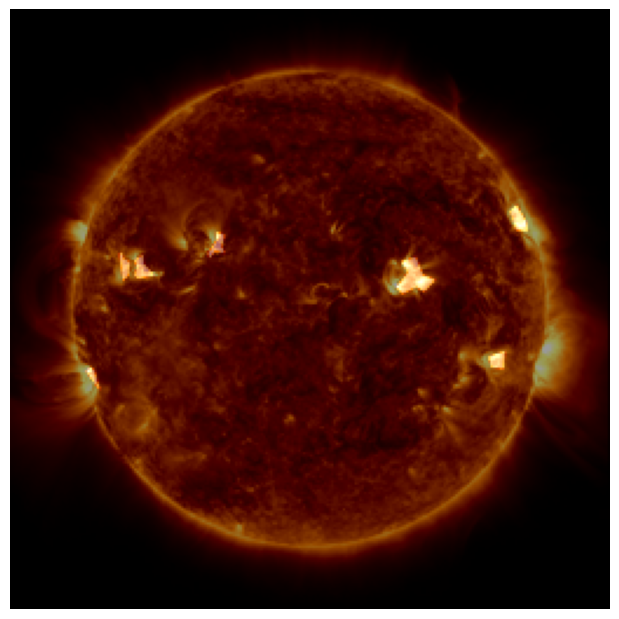

In [ ]:
# Open PNG
file_name = "2013_02_20__23_00_11_34__SDO_AIA_AIA_171_r180"

img = np.array(Image.open(f"C:/Users/User/Master_physics/Space_weather/scss-net/data/171_train/171(spoca)/imgs/{file_name}.png").convert("L"))
label = (np.array(Image.open(f"C:/Users/User/Master_physics/Space_weather/scss-net/data/171_train/171(spoca)/masks/{file_name}.png").convert("L")))

#img = np.array(Image.open(f"C:/Users/User/Master_physics/Space_weather/scss-net/data/193_train_adapted/193(region_growth)/imagesTs_sure/{file_name}.png").convert("L"))
#label = (np.array(Image.open(f"C:/Users/User/Master_physics/Space_weather/scss-net/data/193_train_adapted/193(region_growth)/labelsTs_sure/{file_name}.png").convert("L")))
#np.flip()

# Show the image
fig = plt.figure(figsize=(6, 6), dpi=100, frameon=False)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()
ax.imshow(img, cmap="afmhot", origin="lower")
ax.imshow(label, cmap="afmhot", alpha=0.4, origin="lower")
plt.show()

# plt.imshow(img, cmap="afmhot")  # or use cmap=plt.colormaps['afmhot']
# plt.imshow(label, cmap = "afmhot", alpha = 0.4)
# plt.axis("off")
# plt.margins(0)
# plt.show()

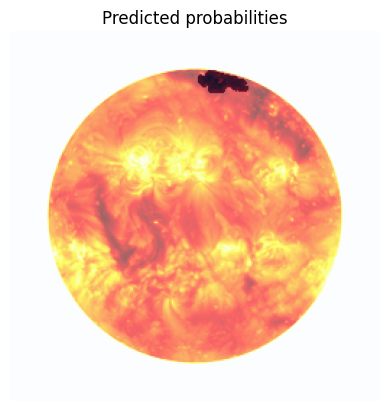

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Ensure inline plotting
%matplotlib inline  


case_num = "0001"

#pred_350 = nib.load(f"C:/Users/User/nnUNet/nnUNet_predictions/Dataset195_SDO_AIA/nnUNetTrainer__Fixed4StagePlannerPlans__2d/checkpoint_epoch_350_with_tta/case_{case_num}.nii.gz").get_fdata()
pred_50 = nib.load(f"C:/Users/User/nnUNet/nnUNet_predictions/Dataset195_SDO_AIA/nnUNetTrainer__Fixed4StagePlannerPlans__2d/checkpoint_epoch_50_with_tta/case_{case_num}.nii.gz").get_fdata()
#pred_200 = nib.load(f"C:/Users/User/nnUNet/nnUNet_predictions/Dataset195_SDO_AIA/nnUNetTrainer__Fixed4StagePlannerPlans__2d/checkpoint_epoch_200_with_tta/case_{case_num}.nii.gz").get_fdata()
gt_label = nib.load(f"C:/Users/User/nnUNet/nnUNet_raw/Dataset195_SDO_AIA/labelsTs/spoca/case_{case_num}.nii.gz").get_fdata()
img_sun = nib.load(f"C:/Users/User/nnUNet/nnUNet_raw/Dataset195_SDO_AIA/imagesTs/case_{case_num}_0000.nii.gz").get_fdata()

gt_label = nib.load(f"C:/Users/User/nnUNet/nnUNet_raw/Dataset196_SDO_AIA/labelsTr/case_{case_num}.nii.gz").get_fdata()
img_sun = nib.load(f"C:/Users/User/nnUNet/nnUNet_raw/Dataset196_SDO_AIA/imagesTr/case_{case_num}_0000.nii.gz").get_fdata()


#gt_label = np.rot90(gt_label, k=2)


# Quick display
#plt.imshow(pred_700, cmap="hot")  # 2D array, probabilities
# plt.imshow(pred_800, cmap= "Reds")
plt.imshow(img_sun, cmap= "hot")

#plt.imshow(pred_350, cmap= "Greens", alpha = 0.4)
#plt.imshow(pred_50, cmap= "Reds", alpha = 0.4)
#plt.imshow(pred_200, cmap= "Reds", alpha = 0.4)
plt.imshow(gt_label, cmap ="Blues", alpha = 0.4)
plt.axis("off")
plt.title("Predicted probabilities")
plt.show()